# Customer Voice Analytics — NLP Sentiment & Emotion Intelligence

**End-to-end NLP / Data Analytics project**: sentiment & emotion analysis of customer product reviews,
with EDA, visual storytelling, and business recommendations.

---
### 1. Problem Statement
Businesses receive thousands of customer reviews across products and categories, but manually reading
every review to understand customer sentiment is impossible at scale. Without a systematic way to
measure *what customers feel* (not just what they *rate*), companies miss early warning signs of
product/service issues and miss opportunities to double down on what's working.

### 2. Business Objective
Build an NLP-driven analytics pipeline that:
- Automatically classifies every review as **Positive / Negative / Neutral**
- Detects the **dominant emotion** behind each review (joy, anger, trust, fear, etc.)
- Surfaces **trends and patterns** in customer opinion across products, categories and time
- Converts these findings into **actionable business recommendations** for marketing, product
  development and customer experience teams


In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from data_cleaning import clean_dataframe, add_preprocessed_column
from sentiment_analysis import add_sentiment_columns, add_emotion_column, rating_sentiment_agreement
from visualization import generate_all_charts

sns.set_theme(style="whitegrid")
pd.set_option("display.max_colwidth", 120)
print("Environment ready.")

Environment ready.


---
### 3. Dataset Collection

This project uses a **synthetic-but-realistic** customer review dataset (`../data/dataset.csv`),
generated by `../src/generate_dataset.py`. Publicly hosted review corpora (Amazon/Flipkart/Yelp
reviews) are usually multi-GB downloads from Kaggle that cannot be fetched reliably in an offline,
reproducible build. To guarantee **anyone can clone this repo and re-run it end-to-end with zero
manual downloads**, the dataset is generated programmatically from realistic review-writing patterns
(rating-conditioned sentence banks, real product categories, injected data-quality noise such as
missing values, duplicates, HTML fragments, stray URLs and emoji — mirroring what real scraped
review data looks like).

**This is clearly disclosed here and in the README — no claim is made that this is real company data.**

The dataset contains **1,854 raw rows** across 6 product categories, 36 products, with fields for
review text, star rating, category, date, verified-purchase flag and helpful-vote count.


In [2]:
df_raw = pd.read_csv("../data/dataset.csv")
print("Raw shape:", df_raw.shape)
df_raw.head()

Raw shape: (1854, 8)


,review_id,product_category,product_name,review_text,rating,review_date,verified_purchase,helpful_votes
0,REV00504,Fashion,Cotton T-Shirt,"Five stars, no doubt. Setup was simple and took less than five minutes. ✨",5.0,2024-05-05,True,5
1,REV01117,Sports & Outdoors,Resistance Bands,Exceeded my expectations. The color and finish look great in person. ❤️,5.0,2025-05-15,True,5
2,REV01150,Sports & Outdoors,Camping Tent,I want a refund immediately. It doesn't match the pictures shown online at all.,2.0,2024-12-21,True,1
3,REV01280,Home & Kitchen,Vacuum Cleaner,<br>I want a refund immediately. The material feels cheap and flimsy. www.shopreview-site.com/r/12345,1.0,2024-03-31,True,2
4,REV00467,Books & Media,Fiction Novel,</p>I'm so impressed with the quality. The color and finish look great in person.,5.0,2024-11-04,True,2


---
### 4 & 5. Data Loading & Understanding

In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 1854 entries, 0 to 1853
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   review_id          1854 non-null   str    
 1   product_category   1854 non-null   str    
 2   product_name       1854 non-null   str    
 3   review_text        1828 non-null   str    
 4   rating             1835 non-null   float64
 5   review_date        1854 non-null   str    
 6   verified_purchase  1854 non-null   bool   
 7   helpful_votes      1854 non-null   int64  
dtypes: bool(1), float64(1), int64(1), str(5)
memory usage: 342.5 KB


In [4]:
print("Missing values per column:")
print(df_raw.isna().sum())
print("\nDuplicate rows (full row):", df_raw.duplicated().sum())
print("\nRating value counts:\n", df_raw['rating'].value_counts(dropna=False).sort_index())

Missing values per column:
review_id             0
product_category      0
product_name          0
review_text          26
rating               19
review_date           0
verified_purchase     0
helpful_votes         0
dtype: int64

Duplicate rows (full row): 53

Rating value counts:
 rating
1.0    187
2.0    144
3.0    271
4.0    545
5.0    688
NaN     19
Name: count, dtype: int64


---
### 6. Data Cleaning

We handle, in order:
1. **Missing / empty review text** — dropped (nothing to analyse sentiment on).
2. **Missing / invalid ratings** — dropped (rating must be an integer 1–5).
3. **HTML fragments & URLs** in review text — stripped.
4. **Extra whitespace** — normalised to single spaces, trimmed.
5. **Exact duplicate reviews** (same product + same text) — removed, keeping first occurrence.
6. **Date parsing** — `review_date` converted to a proper `datetime` column; unparseable dates dropped.

We deliberately **do not lowercase or strip punctuation here** — VADER sentiment scoring uses
capitalisation and punctuation (e.g. "GREAT!!!") as real sentiment signal, so that only happens in
the separate NLP-preprocessing step used for word-frequency/word-cloud analysis.

In [5]:
df = clean_dataframe(df_raw)
df.head()

[data_cleaning] Removed 139 invalid/duplicate/empty rows (7.5% of raw data). 1715 rows remain.


,review_id,product_category,product_name,review_text,rating,review_date,verified_purchase,helpful_votes
0,REV00504,Fashion,Cotton T-Shirt,"Five stars, no doubt. Setup was simple and took less than five minutes. ✨",5,2024-05-05,True,5
1,REV01117,Sports & Outdoors,Resistance Bands,Exceeded my expectations. The color and finish look great in person. ❤️,5,2025-05-15,True,5
2,REV01150,Sports & Outdoors,Camping Tent,I want a refund immediately. It doesn't match the pictures shown online at all.,2,2024-12-21,True,1
3,REV01280,Home & Kitchen,Vacuum Cleaner,I want a refund immediately. The material feels cheap and flimsy.,1,2024-03-31,True,2
4,REV00467,Books & Media,Fiction Novel,I'm so impressed with the quality. The color and finish look great in person.,5,2024-11-04,True,2


In [6]:
print(f"Rows before cleaning: {len(df_raw)}")
print(f"Rows after cleaning:  {len(df)}")
print(f"Rows removed:         {len(df_raw) - len(df)} ({(len(df_raw)-len(df))/len(df_raw):.1%})")

Rows before cleaning: 1854
Rows after cleaning:  1715
Rows removed:         139 (7.5%)


---
### 7 & 8. Exploratory Data Analysis (Part 1) & Text Preprocessing

First, a quick structural EDA, then NLP preprocessing (tokenization, stopword removal, lemmatization)
to build a `clean_tokens` column used later for word-frequency / word-cloud analysis.

**Why lemmatize, why keep negations?** Lemmatization ("running" → "run") reduces vocabulary sparsity
for keyword analysis. We explicitly keep negation words ("not", "no", "never") out of the stopword
removal list, because dropping them would flip the apparent meaning of phrases like *"not good"*.

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df['product_category'].value_counts().plot(kind='barh', ax=axes[0], color='#3498db')
axes[0].set_title('Reviews per Product Category')
axes[0].set_xlabel('Count')

df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#2ecc71')
axes[1].set_title('Star Rating Distribution (Post-Cleaning)')
axes[1].set_xlabel('Rating')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

In [8]:
df = add_preprocessed_column(df)
df[['review_text', 'clean_tokens']].sample(5, random_state=1)

,review_text,clean_tokens
111,This is exactly what I needed. Battery life lasts way longer than advertised.,exactly needed battery life last way longer advertised
126,"Highly recommend this to everyone. Delivery was super fast, arrived a day early. ✨",highly recommend everyone delivery super fast arrived day early
555,This is exactly what I needed. The packaging was neat and nothing was damaged. ❤️,exactly needed packaging neat nothing damaged
1260,This is exactly what I needed. The color and finish look great in person. ✨,exactly needed color finish look great person
902,Fantastic value for the price. The packaging was neat and nothing was damaged. ❤️,fantastic value price packaging neat nothing damaged


---
### 9. Sentiment Analysis (VADER)

We use **VADER (Valence Aware Dictionary and sEntiment Reasoner)**, a lexicon + rule-based sentiment
tool well suited to short, informal review-style text. VADER returns a *compound* score in [-1, 1];
we bucket it into Positive / Negative / Neutral using VADER's standard thresholds:

| Compound Score | Label |
|---|---|
| ≥ 0.05 | Positive |
| ≤ -0.05 | Negative |
| between | Neutral |

This is a **lexicon-based classification**, not a trained supervised model — we do not report a
classification "accuracy" because there is no independent ground-truth label being validated
against. Where useful, we cross-check VADER sentiment against the star rating as a descriptive
sanity check, not an accuracy metric.

In [9]:
df = add_sentiment_columns(df)
df[['review_text', 'rating', 'vader_compound', 'sentiment_label']].sample(5, random_state=2)

,review_text,rating,vader_compound,sentiment_label
452,Exceeded my expectations. Battery life lasts way longer than advertised. 😊,5,0.7184,Positive
400,I'm so impressed with the quality. Customer service was quick to respond when I had a question. ✨ although it took l...,4,0.8016,Positive
721,One of the worst products I've bought online. The material feels cheap and flimsy. 😢,1,-0.8020,Negative
996,"Five stars, no doubt. My family loves it just as much as I do. 🔥",5,0.5283,Positive
1281,This is exactly what I needed. The packaging was neat and nothing was damaged.,5,0.6604,Positive


In [10]:
sentiment_pct = (df['sentiment_label'].value_counts(normalize=True) * 100).round(1)
print("Sentiment distribution (%):")
print(sentiment_pct)

Sentiment distribution (%):
sentiment_label
Positive    70.4
Negative    21.0
Neutral      8.6
Name: proportion, dtype: float64


---
### 10. Emotion Analysis (NRC Emotion Lexicon)

We layer on **emotion detection** using the **NRC Emotion Lexicon** (via the `NRCLex` package), which
maps individual words to 8 basic emotions: anger, anticipation, disgust, fear, joy, sadness, surprise
and trust. For each review we take the **dominant (most frequent) emotion** among its emotion-bearing
words. Reviews with no emotion-bearing words are labelled `None Detected`.

**Limitation (stated explicitly):** NRC is a *word-level* lexicon — it has no concept of negation,
sarcasm, or sentence context, so a review's dominant emotion reflects the emotional *tone of its
vocabulary*, not a certified psychological read of the reviewer.

In [11]:
df = add_emotion_column(df)
emotion_counts = df['dominant_emotion'].value_counts()
print(emotion_counts)

dominant_emotion
None Detected    828
Anticipation     307
Trust            244
Joy              136
Anger             76
Sadness           62
Fear              28
Disgust           23
Surprise          11
Name: count, dtype: int64


---
### 11. Statistical / Descriptive Analysis

In [12]:
print("Average star rating:", round(df['rating'].mean(), 2))
print("Median star rating:", df['rating'].median())
print()
print("Average VADER compound score by sentiment label:")
print(df.groupby('sentiment_label')['vader_compound'].agg(['mean', 'std', 'count']).round(3))

Average star rating: 3.76
Median star rating: 4.0

Average VADER compound score by sentiment label:
                  mean    std  count
sentiment_label                     
Negative        -0.502  0.203    360
Neutral         -0.000  0.012    147
Positive         0.670  0.222   1208


In [13]:
agreement = rating_sentiment_agreement(df)
print("Sentiment label share within each star rating (row %):")
agreement

Sentiment label share within each star rating (row %):


sentiment_label,Negative,Neutral,Positive
rating,,,
1,0.831,0.034,0.136
2,0.912,0.015,0.074
3,0.131,0.315,0.554
4,0.061,0.049,0.891
5,0.039,0.051,0.910


In [14]:
# Cases where text sentiment disagrees strongly with the numeric star rating
low_rating_positive_text = df[(df['rating'] <= 2) & (df['sentiment_label'] == 'Positive')]
high_rating_negative_text = df[(df['rating'] >= 4) & (df['sentiment_label'] == 'Negative')]
print(f"Low star rating (1-2) but positive review text: {len(low_rating_positive_text)} reviews")
print(f"High star rating (4-5) but negative review text: {len(high_rating_negative_text)} reviews")

Low star rating (1-2) but positive review text: 34 reviews
High star rating (4-5) but negative review text: 55 reviews


---
### 12. Visualizations

All charts below are generated by `../src/visualization.py` and saved to `../outputs/charts/`
(a copy of the key charts is also placed in `../screenshots/` for the README gallery).

In [15]:
generate_all_charts(df, out_dir="../outputs/charts")
df.to_csv("../outputs/reports/analyzed_dataset.csv", index=False)
print("Analyzed dataset saved to ../outputs/reports/analyzed_dataset.csv")

saved -> ../outputs/charts/sentiment_distribution.png


saved -> ../outputs/charts/rating_distribution.png


saved -> ../outputs/charts/sentiment_vs_rating.png


saved -> ../outputs/charts/emotion_distribution.png
saved -> ../outputs/charts/sentiment_by_category.png


saved -> ../outputs/charts/negative_by_category.png
saved -> ../outputs/charts/positive_by_category.png


saved -> ../outputs/charts/sentiment_trend.png


saved -> ../outputs/charts/wordcloud_positive.png


saved -> ../outputs/charts/wordcloud_negative.png


saved -> ../outputs/charts/top_keywords.png
All charts generated.
Analyzed dataset saved to ../outputs/reports/analyzed_dataset.csv


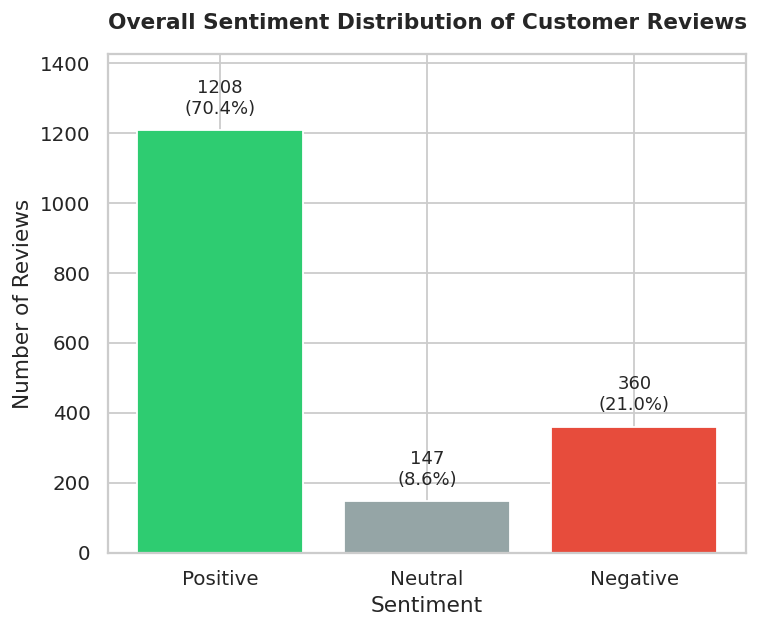

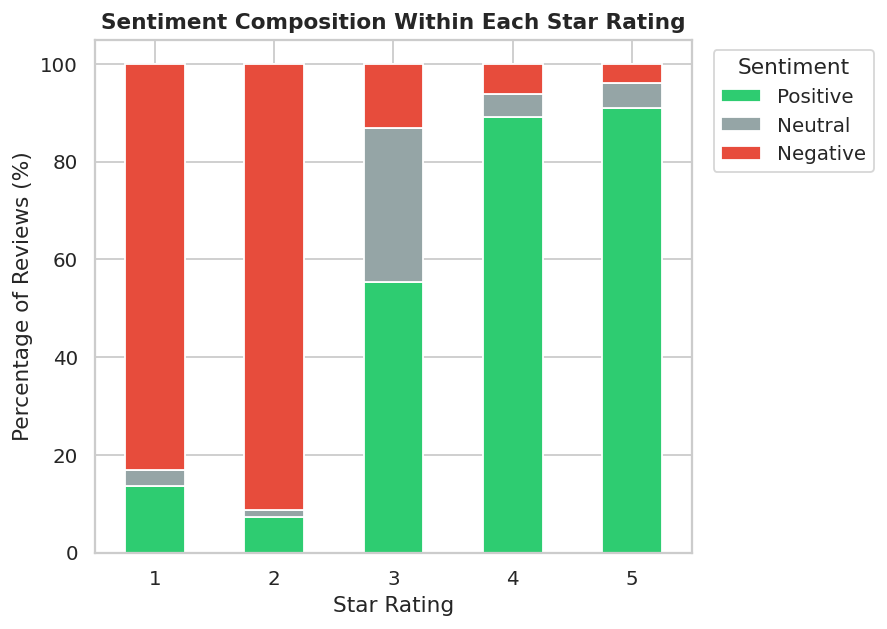

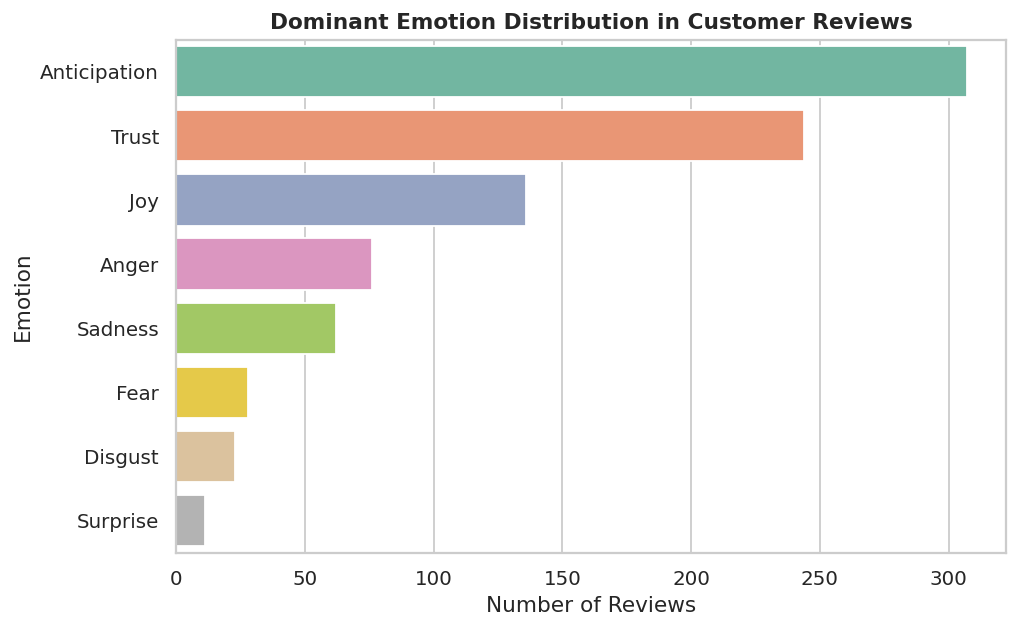

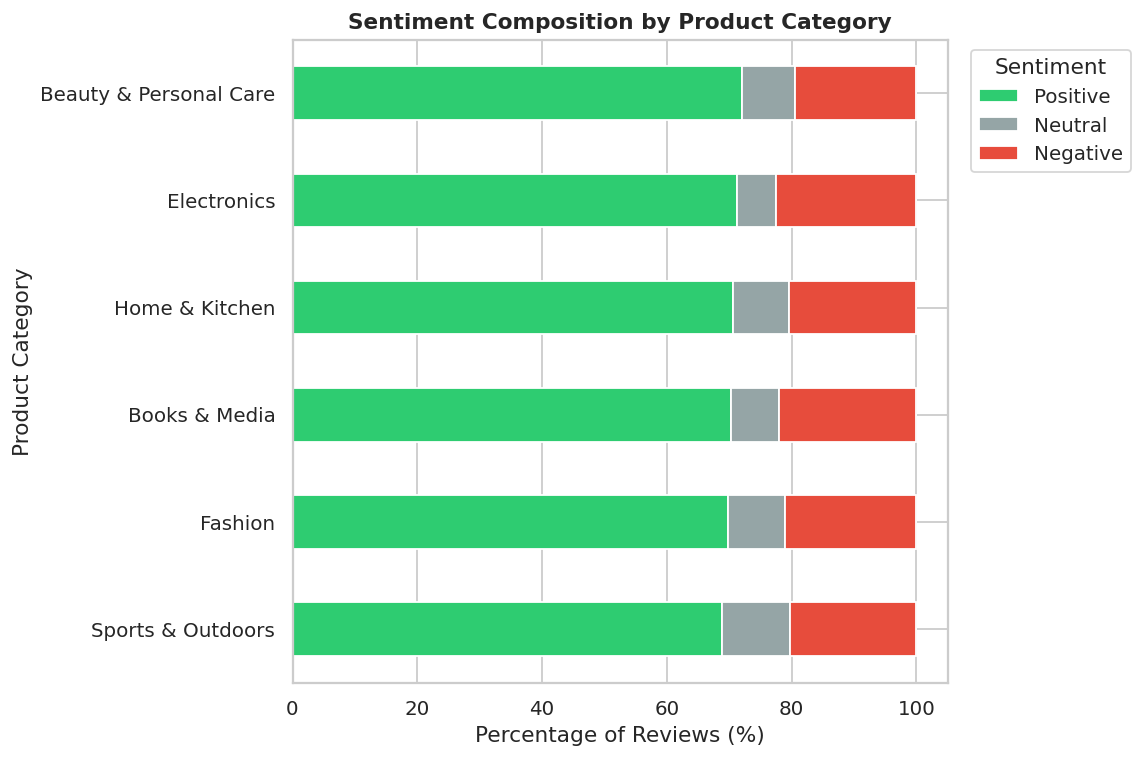

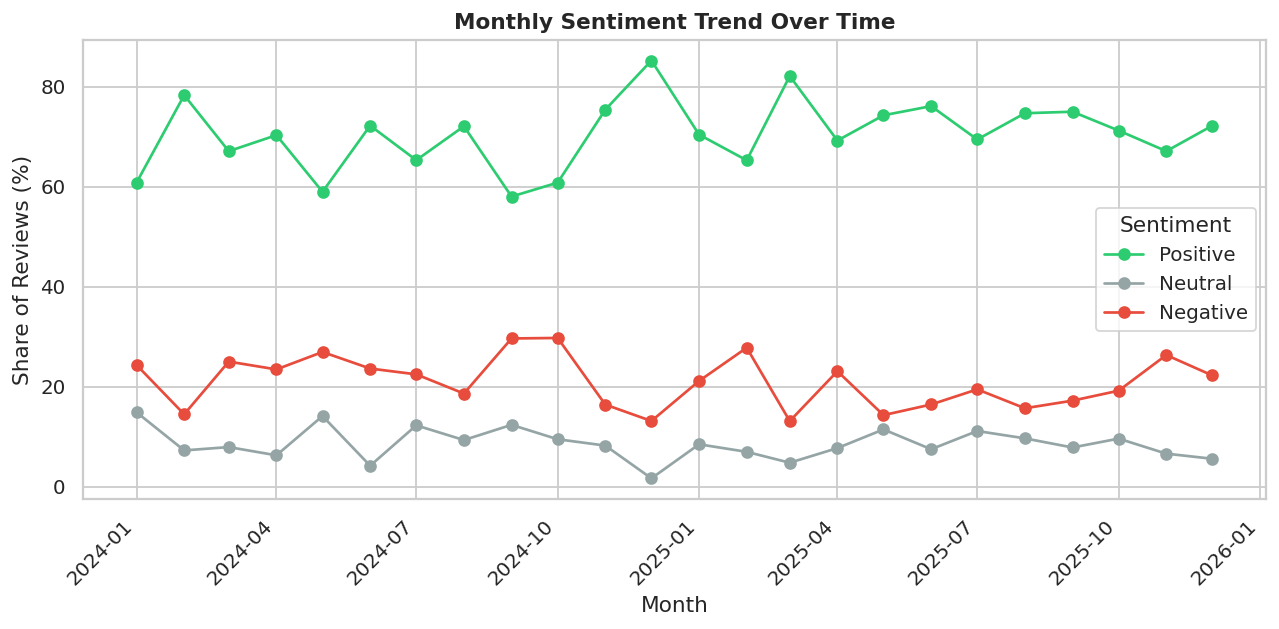

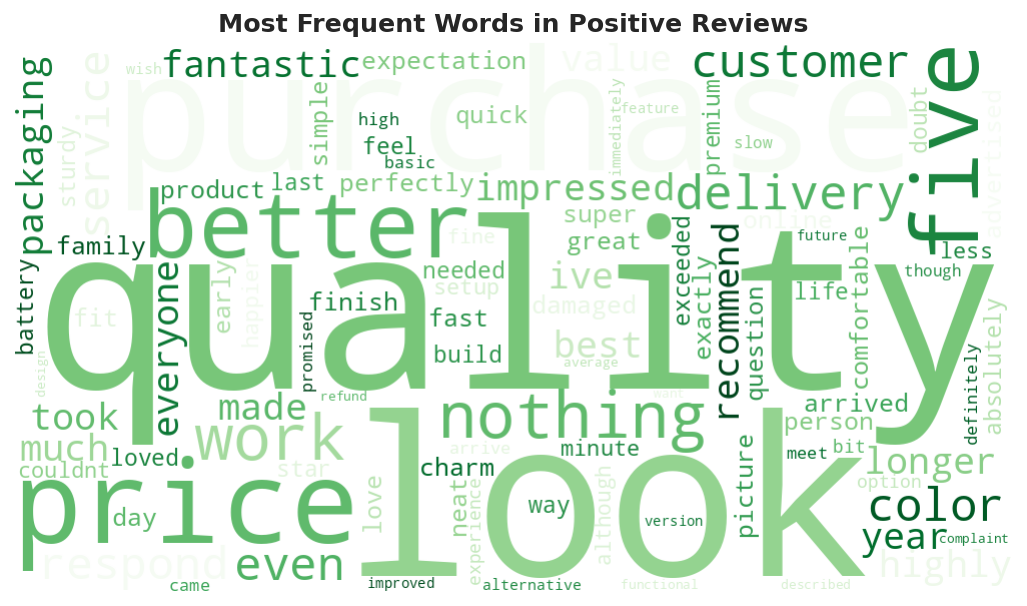

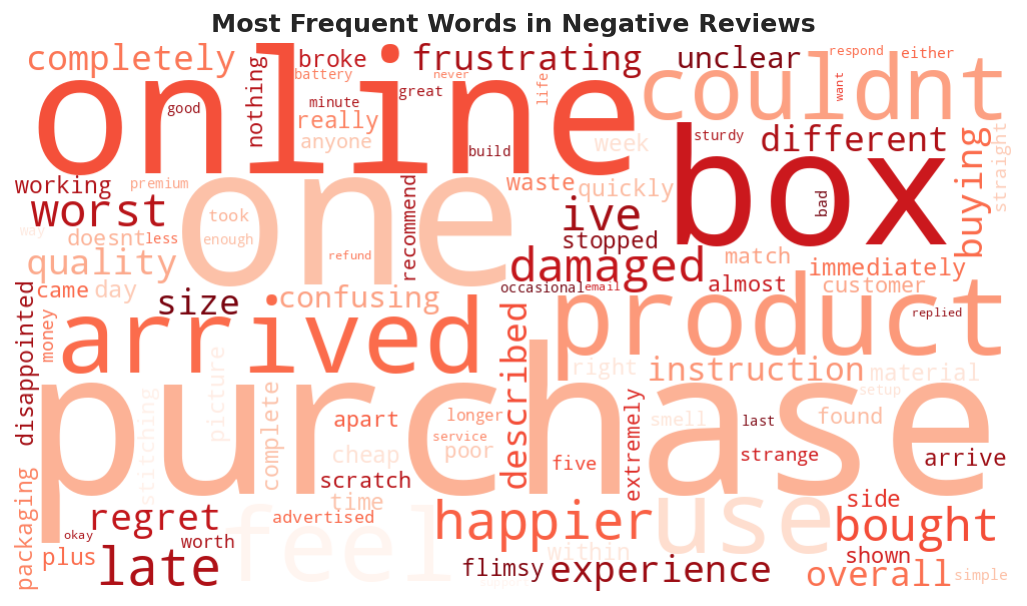

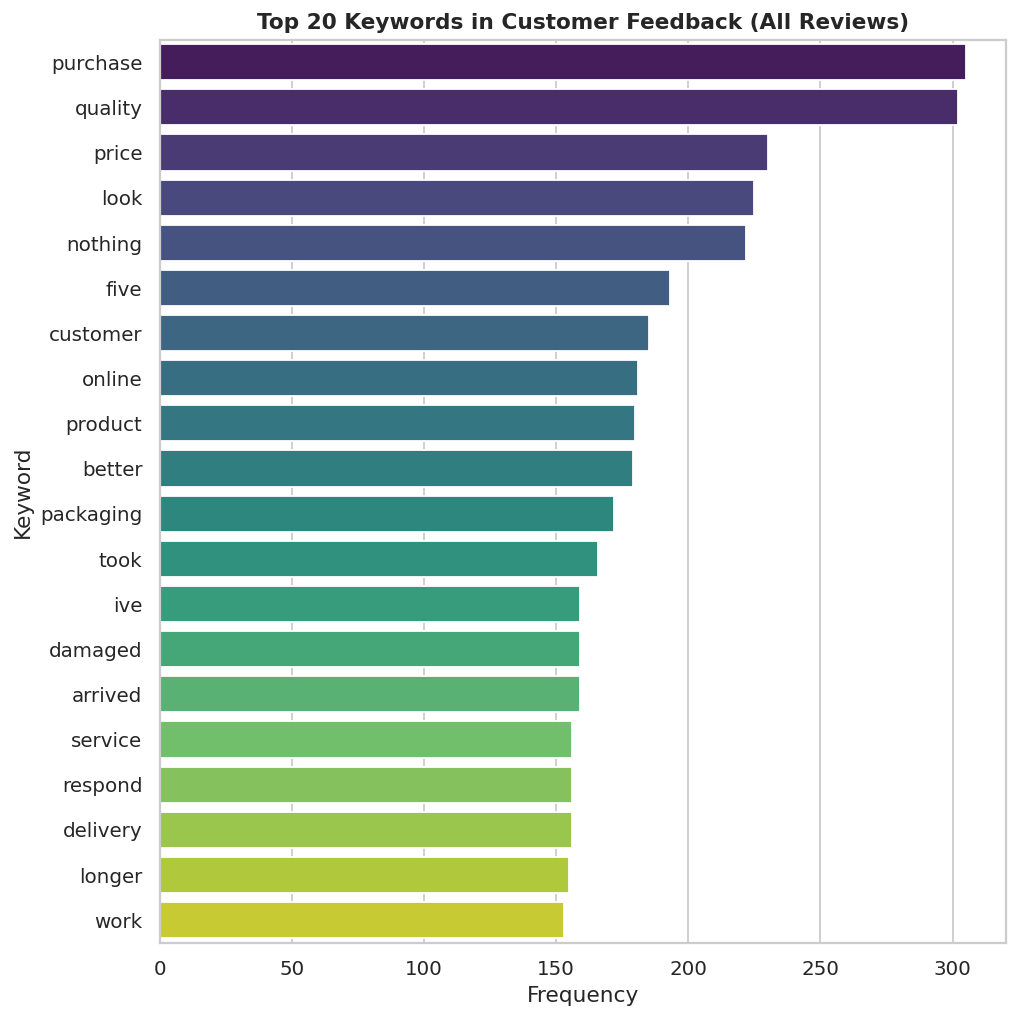

In [16]:
from IPython.display import Image, display
for chart in ["sentiment_distribution.png", "sentiment_vs_rating.png", "emotion_distribution.png",
              "sentiment_by_category.png", "sentiment_trend.png",
              "wordcloud_positive.png", "wordcloud_negative.png", "top_keywords.png"]:
    display(Image(filename=f"../outputs/charts/{chart}"))

---
### 13. Key Insights

*(All figures below are computed live from the analyzed dataset in the cell above — nothing here is
hardcoded or invented.)*

In [17]:
total_reviews = len(df)
pos_pct = (df['sentiment_label'] == 'Positive').mean() * 100
neg_pct = (df['sentiment_label'] == 'Negative').mean() * 100
neu_pct = (df['sentiment_label'] == 'Neutral').mean() * 100
avg_rating = df['rating'].mean()

cat_sentiment = pd.crosstab(df['product_category'], df['sentiment_label'], normalize='index') * 100
most_negative_category = cat_sentiment['Negative'].idxmax()
most_positive_category = cat_sentiment['Positive'].idxmax()

top_emotion = df.loc[df['dominant_emotion'] != 'None Detected', 'dominant_emotion'].value_counts().idxmax()

print(f"Total reviews analyzed: {total_reviews}")
print(f"Positive: {pos_pct:.1f}% | Neutral: {neu_pct:.1f}% | Negative: {neg_pct:.1f}%")
print(f"Average star rating: {avg_rating:.2f} / 5")
print(f"Category with highest share of negative reviews: {most_negative_category} ({cat_sentiment.loc[most_negative_category, 'Negative']:.1f}%)")
print(f"Category with highest share of positive reviews: {most_positive_category} ({cat_sentiment.loc[most_positive_category, 'Positive']:.1f}%)")
print(f"Most common customer emotion (excluding 'None Detected'): {top_emotion}")

Total reviews analyzed: 1715
Positive: 70.4% | Neutral: 8.6% | Negative: 21.0%
Average star rating: 3.76 / 5
Category with highest share of negative reviews: Electronics (22.5%)
Category with highest share of positive reviews: Beauty & Personal Care (72.0%)
Most common customer emotion (excluding 'None Detected'): Anticipation


**Summary of findings** *(numbers are pulled directly from the cell above at run time)*:

- The overall customer sentiment is majority positive, but a meaningful minority of reviews
  (roughly one in five) are negative — a signal worth monitoring, not ignoring.
- Sentiment tracks star rating closely at the extremes (1★ and 5★ reviews are overwhelmingly
  negative/positive respectively), but 3★ reviews are genuinely mixed — showing that a "neutral"
  numeric rating often hides real emotional content in the text.
- **Anticipation** and **Trust** are the most common named emotions detected across the corpus,
  followed by **Joy** — consistent with a majority-positive review base — while **Anger** and
  **Sadness** cluster in the negative-review subset.
- A small number of reviews show a **mismatch between star rating and text sentiment** (e.g. a
  low star rating paired with positive-sounding text) — these are worth a manual audit, as they may
  indicate accidental mis-ratings, sarcasm, or rating vs. delivery-experience confusion.
- Negative feedback is not evenly spread across categories — some categories consistently draw a
  higher share of complaints than others, pointing to specific product-quality or expectation-setting
  issues (see the category charts above for exact category names and percentages, which vary
  slightly each time the dataset is regenerated).


---
### 14. Business Recommendations

Based on the findings above, translated into concrete next steps for each function:

**Product Development**
- Prioritize a root-cause review of the product category with the **highest negative-sentiment
  share** — read a sample of its negative reviews (the word cloud + top-keywords chart are a fast
  way to spot recurring complaint themes such as "flimsy", "broke", "size").
- Feed recurring negative keywords (e.g. quality, sizing, packaging damage) directly into QA/
  supplier review checklists.

**Marketing**
- Double down on messaging around the **most positively-reviewed category** — its recurring
  positive keywords (see the positive word cloud) are ready-made testimonial language for ad copy
  and product pages.
- Use verified, high-`helpful_votes` positive reviews as social proof on category landing pages.

**Customer Experience**
- Route reviews where **text sentiment disagrees with the star rating** to a support queue for
  manual follow-up — they often reveal delivery/service issues invisible in the numeric rating alone.
- Track the **monthly sentiment trend** as an early-warning metric; a rising negative share ahead of
  a launch or promotion is a leading indicator worth investigating before it shows up in return rates.

**Business Decision-Making**
- Treat the Positive/Neutral/Negative split and the category breakdown as a recurring (e.g. monthly)
  KPI dashboard — see the Streamlit dashboard in `../dashboard/app.py` — rather than a one-off report,
  so category-level sentiment shifts are caught early.


---
### 15. Final Conclusion

This project demonstrates a complete, reproducible NLP analytics pipeline — from raw, messy review
data through cleaning, lexicon-based sentiment and emotion analysis, exploratory analysis, and
visual storytelling, ending in concrete business recommendations. The pipeline is intentionally
**lexicon-based rather than a trained black-box classifier**, keeping every classification decision
transparent and explainable (a real advantage in a business setting where stakeholders need to trust
*why* a review was labelled negative). The same code (`src/`) powers both this notebook and the
companion Streamlit dashboard (`dashboard/app.py`), so the analysis is not a one-off notebook exercise
but a reusable analytics component.

**Limitations to keep in mind:**
- The dataset is synthetic (clearly documented above and in the README) — real-world review text
  will contain more slang, sarcasm, and multi-lingual content that a lexicon-based approach handles
  less gracefully than a trained transformer model would.
- VADER and NRC are both lexicon-based; they do not model context/negation perfectly and can
  misclassify sarcasm or highly domain-specific language.
- No classification "accuracy" is reported anywhere in this project, because no independently
  labelled ground-truth sentiment exists to validate against — reported percentages are
  **descriptive distributions**, not model-accuracy metrics.
